In [23]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch

In [25]:
all_data  = pd.read_csv("new_nifty_top15_prices_2010_2024.csv",index_col= "Date" ,parse_dates = ["Date"]).dropna()

In [27]:
all_data_log  = np.log(all_data/all_data.shift()).dropna()

In [29]:
all_data_log["Target"] = all_data_log["^NSEI"].shift(-1)

In [33]:
all_data_log.drop(columns = "^NSEI" , inplace =  True)

In [37]:
all_data_log.columns

Index(['AXISBANK.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'HCLTECH.NS',
       'HDFCBANK.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS',
       'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'RELIANCE.NS', 'SBIN.NS', 'TCS.NS',
       'Target'],
      dtype='object')

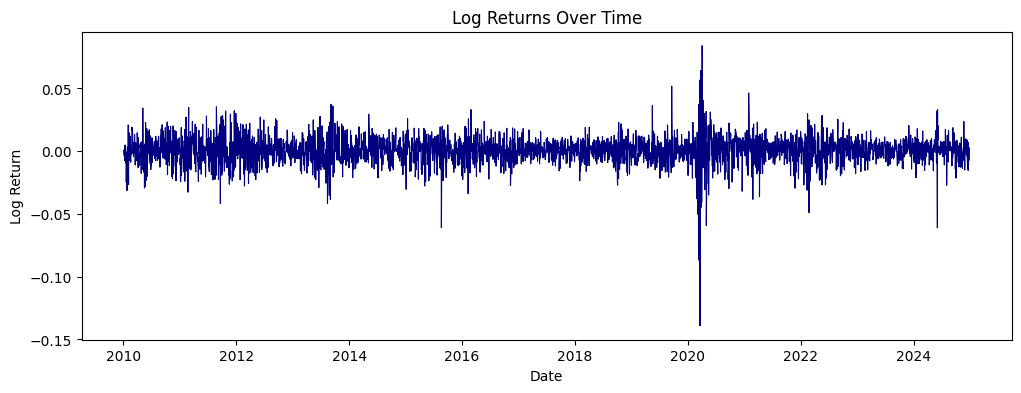

In [41]:
plt.figure(figsize=(12,4))
plt.plot(all_data_log.index, all_data_log['Target'], color='navy', linewidth=0.8)
plt.title('Log Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.show()

# What you get: return movement over time.
# Why we use it: to see volatility clustering, where calm periods and turbulent periods appear together.


In [51]:
from statsmodels.stats.diagnostic import het_arch

lm_stat, p_value, _, _ = het_arch(all_data_log['Target'].dropna())

if p_value< 0.05:
    print ("p-value < 0.05 → ARCH effect exists → GARCH is justified.")
else :
    print("p-value > 0.05 → little evidence of volatility clustering.")

# this is to check volaoty clusrting is there or not 

p-value < 0.05 → ARCH effect exists → GARCH is justified.


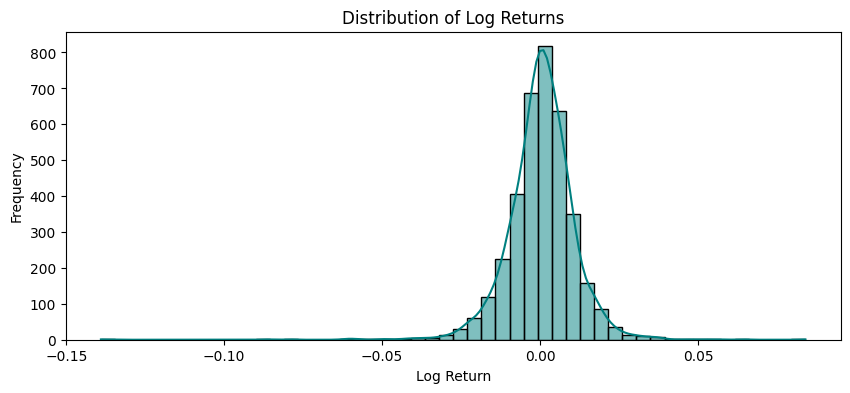

In [53]:
# now checking normal distribution it follow or other 
plt.figure(figsize=(10,4))
sns.histplot(all_data_log['Target'], bins=50, kde=True, color='teal')
plt.title('Distribution of Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

# What you get: shape of return distribution.
# Why we use it: to check skewness, fat tails, and non-normality.

In [67]:

skw = all_data_log['Target'].skew()
kur = all_data_log['Target'].kurtosis()

if abs(skw) < 0.5 and kur <= 3:
    print(f"Target variable approximately follows a normal distribution. "
          f"Skew = {skw:.4f}, Kurtosis = {kur:.4f}")
else:
    print(f"Target variable does NOT follow a normal distribution. "
          f"Skew = {skw:.4}, Kurtosis = {kur:.4}")

Target variable does NOT follow a normal distribution. Skew = -0.9305, Kurtosis = 13.58


In [77]:
from scipy.stats import jarque_bera

jb_stat, p_value = jarque_bera(all_data_log['Target'].dropna())

if p_value < 0.05:
    print("Reject H0: data does NOT follow a normal distribution")
else:
    print("Fail to reject H0: data approximately follows a normal distribution")
    

Reject H0: data does NOT follow a normal distribution


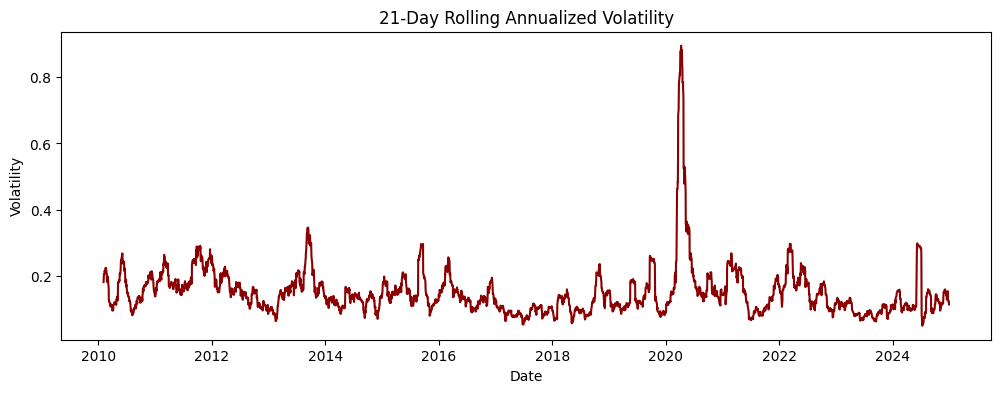

In [79]:
window = 21
all_data_log['Target']= all_data_log['Target'].rolling(window).std() * np.sqrt(252)

plt.figure(figsize=(12,4))
plt.plot(all_data_log.index, all_data_log['Target'], color='darkred')
plt.title(f'{window}-Day Rolling Annualized Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

# What you get: time-varying volatility estimate.
# Why we use it: volatility is not constant, and ARCH/GARCH models are built to capture this.

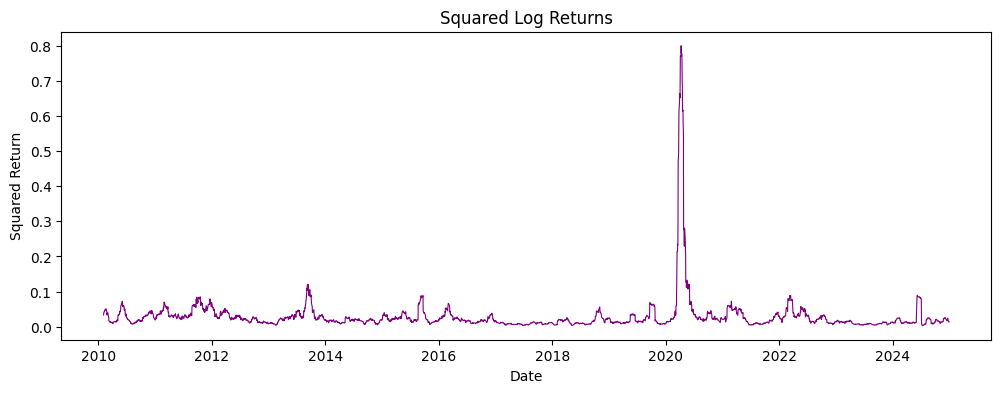

In [81]:
SQ_target = all_data_log['Target']**2

plt.figure(figsize=(12,4))
plt.plot(all_data_log.index, SQ_target, color='purple', linewidth=0.8)
plt.title('Squared Log Returns')
plt.xlabel('Date')
plt.ylabel('Squared Return')
plt.show()

# What you get: spikes in volatility intensity.
# Why we use it: ARCH models are based on the idea that current variance depends on past squared shocks

<Figure size 1000x400 with 0 Axes>

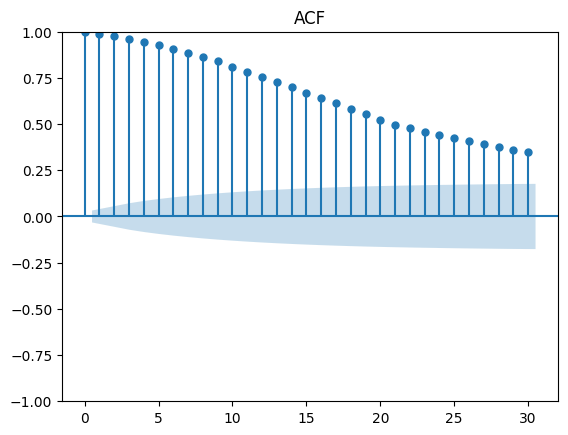

In [85]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(all_data_log['Target'].dropna(), lags=30)
plt.title('ACF')
plt.show()

<Figure size 1000x400 with 0 Axes>

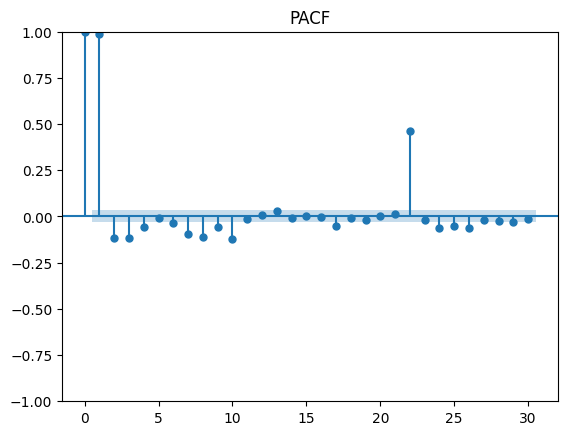

In [93]:
plt.figure(figsize=(10,4))
plot_pacf(all_data_log['Target'].dropna(), lags=30)
plt.title('PACF')
plt.show()


<Figure size 1000x400 with 0 Axes>

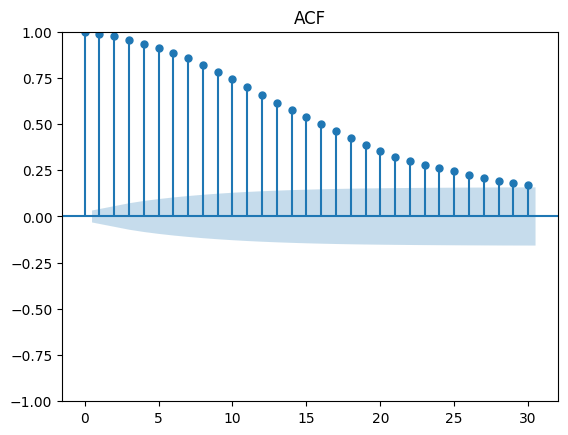

In [95]:
plt.figure(figsize=(10,4))
plot_acf(SQ_target.dropna(), lags=30)
plt.title('ACF')
plt.show()

<Figure size 1000x400 with 0 Axes>

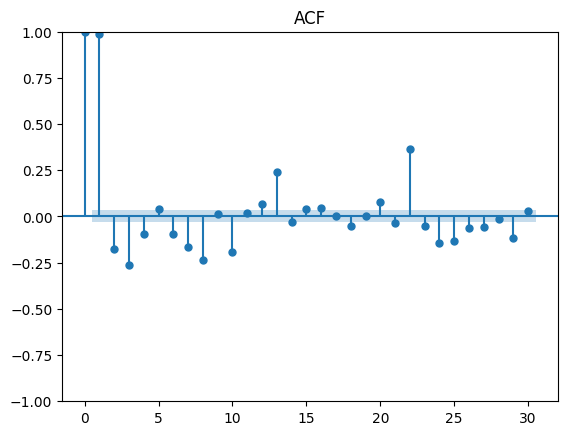

In [97]:
plt.figure(figsize=(10,4))
plot_pacf(SQ_target.dropna(), lags=30)
plt.title('ACF')
plt.show()

<Figure size 600x600 with 0 Axes>

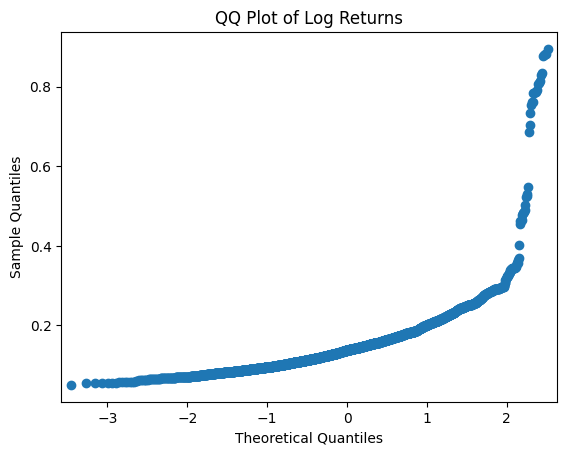

In [103]:
from statsmodels.graphics.gofplots import qqplot

plt.figure(figsize=(6,6))
qqplot(all_data_log['Target'], line='s')
plt.title('QQ Plot of Log Returns')
plt.show()

# What you get: comparison of your return distribution to normal distribution.
# Why we use it: financial returns often have heavy tails, so normality usually fails.

In [107]:
from statsmodels.tsa.stattools import adfuller, kpss

# Use log returns for stationarity check
returns = all_data_log['Target'].dropna()

# ADF test
adf_stat, adf_pvalue, adf_lags, adf_nobs, adf_crit, adf_icbest = adfuller(returns, autolag='AIC')

print("ADF Test")
print("ADF Statistic:", adf_stat)
print("p-value:", adf_pvalue)
print("Used Lags:", adf_lags)
print("No. of Observations:", adf_nobs)
print("Critical Values:")
for key, value in adf_crit.items():
    print(f"   {key}: {value}")

# KPSS test
kpss_stat, kpss_pvalue, kpss_lags, kpss_crit = kpss(returns, regression='c', nlags='auto')

print("\nKPSS Test")
print("KPSS Statistic:", kpss_stat)
print("p-value:", kpss_pvalue)
print("Used Lags:", kpss_lags)
print("Critical Values:")
for key, value in kpss_crit.items():
    print(f"   {key}: {value}")

ADF Test
ADF Statistic: -6.542589944970128
p-value: 9.266934671326342e-09
Used Lags: 30
No. of Observations: 3626
Critical Values:
   1%: -3.432154725699155
   5%: -2.8623374271161723
   10%: -2.567194482813802

KPSS Test
KPSS Statistic: 0.3078448958189394
p-value: 0.1
Used Lags: 38
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


C:\Users\Dell\anaconda3\envs\aryanquants\lib\site-packages\statsmodels\tsa\stattools.py:2023: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warn_msg.format(direction="greater"), InterpolationWarning


In [113]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# use stationary log returns from previous step
returns = all_data_log['Target'].dropna()

results = []

# 1. Constant mean model -> ARIMA(0,0,0)
try:
    model_000 = ARIMA(returns, order=(0,0,0)).fit()
    lb_000 = acorr_ljungbox(model_000.resid, lags=[10], return_df=True)
    results.append({
        'Model': 'Constant Mean',
        'Order': '(0,0,0)',
        'AIC': model_000.aic,
        'BIC': model_000.bic,
        'LjungBox_pvalue': lb_000['lb_pvalue'].iloc[0]
    })
except Exception as e:
    print("Constant Mean model failed:", e)

# 2. AR(1)
try:
    model_100 = ARIMA(returns, order=(1,0,0)).fit()
    lb_100 = acorr_ljungbox(model_100.resid, lags=[10], return_df=True)
    results.append({
        'Model': 'AR(1)',
        'Order': '(1,0,0)',
        'AIC': model_100.aic,
        'BIC': model_100.bic,
        'LjungBox_pvalue': lb_100['lb_pvalue'].iloc[0]
    })
except Exception as e:
    print("AR(1) model failed:", e)

# 3. Small ARMA grid search
for p in range(0, 3):
    for q in range(0, 3):
        if (p, q) == (0, 0) or (p, q) == (1, 0):
            continue
        try:
            model = ARIMA(returns, order=(p,0,q)).fit()
            lb = acorr_ljungbox(model.resid, lags=[10], return_df=True)
            results.append({
                'Model': f'ARMA({p},{q})',
                'Order': f'({p},0,{q})',
                'AIC': model.aic,
                'BIC': model.bic,
                'LjungBox_pvalue': lb['lb_pvalue'].iloc[0]
            })
        except:
            continue

results_df = pd.DataFrame(results).sort_values(by=['AIC', 'BIC']).reset_index(drop=True)
print(results_df)

best_model_row = results_df.iloc[0]
print("\nBest Mean Model Based on AIC/BIC:")
print(best_model_row)

           Model    Order           AIC           BIC  LjungBox_pvalue
0      ARMA(2,2)  (2,0,2) -22661.354394 -22624.128003     8.175630e-20
1      ARMA(1,2)  (1,0,2) -22633.831356 -22602.809364     1.422873e-27
2      ARMA(2,0)  (2,0,0) -22600.997797 -22576.180203     2.510465e-37
3      ARMA(1,1)  (1,0,1) -22592.161509 -22567.343916     3.924677e-41
4          AR(1)  (1,0,0) -22556.274033 -22537.660838     4.031834e-62
5      ARMA(2,1)  (2,0,1) -22483.986354 -22452.964362     7.085751e-37
6      ARMA(0,2)  (0,0,2) -15906.234250 -15881.416656     0.000000e+00
7      ARMA(0,1)  (0,0,1) -12863.166560 -12844.553365     0.000000e+00
8  Constant Mean  (0,0,0)  -8505.290837  -8492.882040     0.000000e+00

Best Mean Model Based on AIC/BIC:
Model                 ARMA(2,2)
Order                   (2,0,2)
AIC               -22661.354394
BIC               -22624.128003
LjungBox_pvalue             0.0
Name: 0, dtype: object


In [145]:
import pandas as pd
from arch import arch_model

# scale returns
returns = all_data_log['Target'].dropna() * 100

arch_results = []

for p in range(1, 6):
    try:
        model = arch_model(returns, mean="Constant", vol="ARCH", p=p, dist="t")
        res = model.fit(disp="off")
        arch_results.append({
            "Model": f"ARCH({p})",
            "p": p,
            "AIC": res.aic,
            "BIC": res.bic,
            "LogLik": res.loglikelihood
        })
    except Exception as e:
        print(f"ARCH({p}) failed:", e)

arch_results_df = pd.DataFrame(arch_results).sort_values(["AIC", "BIC"]).reset_index(drop=True)
print(arch_results_df)

best_arch_row = arch_results_df.iloc[0]
print("\nBest ARCH Model Based on AIC/BIC:")
print(best_arch_row)

     Model  p           AIC           BIC       LogLik
0  ARCH(3)  3  18874.470167  18911.696557 -9431.235083
1  ARCH(2)  2  18876.736924  18907.758916 -9433.368462
2  ARCH(1)  1  18878.754486  18903.572079 -9435.377243
3  ARCH(4)  4  18879.423074  18922.853863 -9432.711537
4  ARCH(5)  5  18882.228310  18931.863497 -9433.114155

Best ARCH Model Based on AIC/BIC:
Model          ARCH(3)
p                    3
AIC       18874.470167
BIC       18911.696557
LogLik    -9431.235083
Name: 0, dtype: object


In [147]:
import pandas as pd
from arch import arch_model

returns = all_data_log['Target'].dropna() * 100

garch_results = []

for p in range(1, 6):
    for q in range(1, 6):
        try:
            model = arch_model(returns, mean="Constant", vol="GARCH", p=p, q=q, dist="t")
            res = model.fit(disp="off")
            garch_results.append({
                "Model": f"GARCH({p},{q})",
                "p": p,
                "q": q,
                "AIC": res.aic,
                "BIC": res.bic,
                "LogLik": res.loglikelihood
            })
        except Exception as e:
            print(f"GARCH({p},{q}) failed:", e)

garch_results_df = pd.DataFrame(garch_results).sort_values(["AIC", "BIC"]).reset_index(drop=True)
print(garch_results_df)

best_garch_row = garch_results_df.iloc[0]
print("\nBest GARCH Model Based on AIC/BIC:")
print(best_garch_row)

         Model  p  q           AIC           BIC       LogLik
0   GARCH(1,1)  1  1  18872.755921  18903.777913 -9431.377960
1   GARCH(1,2)  1  2  18873.808814  18911.035205 -9430.904407
2   GARCH(2,1)  2  1  18874.762374  18911.988765 -9431.381187
3   GARCH(1,3)  1  3  18875.806999  18919.237788 -9430.903500
4   GARCH(2,2)  2  2  18876.923112  18920.353901 -9431.461556
5   GARCH(3,2)  3  2  18877.785321  18927.420509 -9430.892661
6   GARCH(2,3)  2  3  18877.814571  18927.449758 -9430.907285
7   GARCH(3,1)  3  1  18878.017591  18921.448379 -9432.008795
8   GARCH(1,4)  1  4  18879.305314  18928.940502 -9431.652657
9   GARCH(2,4)  2  4  18879.807366  18935.646951 -9430.903683
10  GARCH(4,1)  4  1  18879.995765  18929.630952 -9431.997882
11  GARCH(3,3)  3  3  18880.565347  18936.404933 -9431.282673
12  GARCH(5,1)  5  1  18881.405625  18937.245211 -9431.702813
13  GARCH(3,4)  3  4  18881.785321  18943.829305 -9430.892660
14  GARCH(5,2)  5  2  18881.799579  18943.843563 -9430.899789
15  GARC

In [148]:
import pandas as pd
from arch import arch_model

returns = all_data_log['Target'].dropna() * 100

EGARCH_results = []

for p in range(1, 6):
    for q in range(1, 6):
        try:
            model = arch_model(returns, mean="Constant", vol="EGARCH", p=p, q=q, dist="t")
            res = model.fit(disp="off")
            EGARCH_results.append({
                "Model": f"EGARCH({p},{q})",
                "p": p,
                "q": q,
                "AIC": res.aic,
                "BIC": res.bic,
                "LogLik": res.loglikelihood
            })
        except Exception as e:
            print(f"EGARCH({p},{q}) failed:", e)

EGARCH_results_df = pd.DataFrame(EGARCH_results).sort_values(["AIC", "BIC"]).reset_index(drop=True)
print(EGARCH_results_df)

best_EGARCH_row = EGARCH_results_df.iloc[0]
print("\nBest EGARCH Model Based on AIC/BIC:")
print(best_EGARCH_row)

C:\Users\Dell\anaconda3\envs\aryanquants\lib\site-packages\arch\univariate\base.py:755: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  ConvergenceWarning,


          Model  p  q            AIC            BIC         LogLik
0   EGARCH(2,1)  2  1   19072.122001   19109.348392   -9530.061001
1   EGARCH(5,1)  5  1   19073.238336   19129.077922   -9527.619168
2   EGARCH(1,3)  1  3   19074.377129   19117.807918   -9530.188565
3   EGARCH(1,1)  1  1   19075.239987   19106.261979   -9532.619993
4   EGARCH(1,5)  1  5   19075.821160   19131.660746   -9528.910580
5   EGARCH(2,2)  2  2   19076.392135   19119.822924   -9531.196068
6   EGARCH(2,4)  2  4   19077.425061   19133.264647   -9529.712531
7   EGARCH(2,5)  2  5   19078.647121   19140.691106   -9529.323561
8   EGARCH(2,3)  2  3   19078.873284   19128.508471   -9531.436642
9   EGARCH(5,5)  5  5   19080.772643   19161.429822   -9527.386321
10  EGARCH(3,3)  3  3   19080.888827   19136.728413   -9531.444414
11  EGARCH(4,5)  4  5   19081.062394   19155.515175   -9528.531197
12  EGARCH(1,4)  1  4   19161.631438   19211.266625   -9572.815719
13  EGARCH(3,5)  3  5   19161.785446   19230.033828   -9569.89

In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.gofplots import qqplot

# target series
returns = all_data_log["Target"].dropna() * 100

# Step 1: Fit ARMA(2,2)
arma22_model = ARIMA(returns, order=(2, 0, 2))
arma22_res = arma22_model.fit()

# Step 2: Take ARMA residuals
arma_resid = arma22_res.resid.dropna()

# Step 3: Fit volatility models on ARMA residuals
arch3_model = arch_model(arma_resid, mean="Zero", vol="ARCH", p=3, dist="t")
arch3_res = arch3_model.fit(disp="off")

garch11_model = arch_model(arma_resid, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
garch11_res = garch11_model.fit(disp="off")

egarch21_model = arch_model(arma_resid, mean="Zero", vol="EGARCH", p=2, q=1, dist="t")
egarch21_res = egarch21_model.fit(disp="off")

In [164]:
models = {
    "ARMA(2,2) + ARCH(3)": arch3_res,
    "ARMA(2,2) + GARCH(1,1)": garch11_res,
    "ARMA(2,2) + EGARCH(2,1)": egarch21_res
}

comparison_rows = []

for name, final_res in models.items():
    std_resid = pd.Series(final_res.std_resid).dropna()

    lb_resid = acorr_ljungbox(std_resid, lags=[10], return_df=True)
    lb_sq = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
    arch_lm = het_arch(std_resid, nlags=10)
    jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(std_resid)

    comparison_rows.append({
        "Model": name,
        "AIC": final_res.aic,
        "BIC": final_res.bic,
        "LB Resid p-value": lb_resid["lb_pvalue"].iloc[0],
        "LB Sq Resid p-value": lb_sq["lb_pvalue"].iloc[0],
        "ARCH LM p-value": arch_lm[1],
        "JB p-value": jb_pvalue,
        "Skewness": skew,
        "Kurtosis": kurtosis
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(
    by=["LB Sq Resid p-value", "ARCH LM p-value", "AIC"],
    ascending=[False, False, True]
).reset_index(drop=True)

print(comparison_df)

                     Model          AIC          BIC  LB Resid p-value  \
0   ARMA(2,2) + GARCH(1,1)  7773.666860  7798.484453      6.974704e-03   
1  ARMA(2,2) + EGARCH(2,1)  7745.114867  7776.136860      5.900414e-03   
2      ARMA(2,2) + ARCH(3)  7821.824540  7852.846532      1.029023e-08   

   LB Sq Resid p-value  ARCH LM p-value  JB p-value  Skewness   Kurtosis  
0         8.781441e-01     8.833830e-01         0.0  0.554695  27.122067  
1         6.431996e-01     6.343779e-01         0.0  0.623923  28.605595  
2         1.093657e-09     1.500743e-09         0.0 -1.654185  55.915330  


In [166]:
best_model_name = comparison_df.loc[0, "Model"]

if best_model_name == "ARMA(2,2) + ARCH(3)":
    final_res = arch3_res
elif best_model_name == "ARMA(2,2) + GARCH(1,1)":
    final_res = garch11_res
elif best_model_name == "ARMA(2,2) + EGARCH(2,1)":
    final_res = egarch21_res

print("Best Final Model:")
print(best_model_name)
print(final_res.summary())

Best Final Model:
ARMA(2,2) + GARCH(1,1)
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3882.83
Distribution:      Standardized Student's t   AIC:                           7773.67
Method:                  Maximum Likelihood   BIC:                           7798.48
                                              No. Observations:                 3657
Date:                      Tue, Jun 23 2026   Df Residuals:                     3657
Time:                              18:16:18   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------

Ljung-Box on standardized residuals
     lb_stat  lb_pvalue
10  24.24552   0.006975

Ljung-Box on squared standardized residuals
     lb_stat  lb_pvalue
10  5.189795   0.878144

ARCH-LM Test
LM stat: 5.114734285511479
LM p-value: 0.8833829579992704
F stat: 0.5106468904223279
F p-value: 0.8838133115995939

Jarque-Bera Test
JB stat: 88850.60246934796
JB p-value: 0.0
Skewness: 0.5546954389723654
Kurtosis: 27.122066829326126


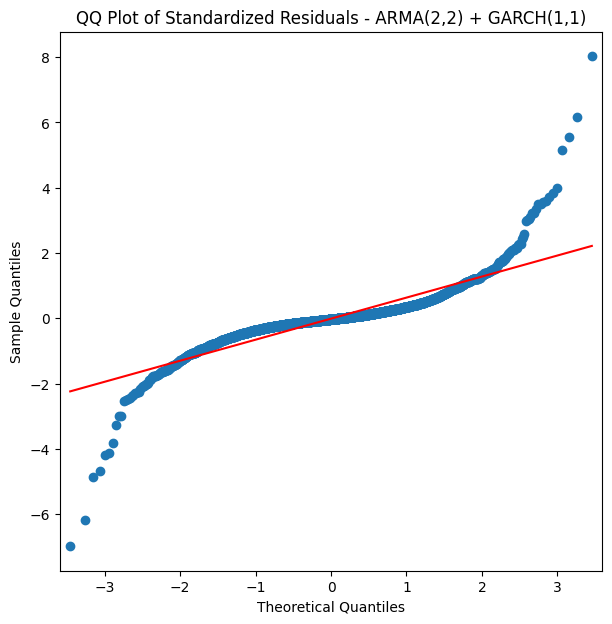

In [168]:
std_resid = final_res.std_resid.dropna()

# 1. Ljung-Box on residuals
lb_resid = acorr_ljungbox(std_resid, lags=[10], return_df=True)
print("Ljung-Box on standardized residuals")
print(lb_resid)

# 2. Ljung-Box on squared residuals
lb_sq = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
print("\nLjung-Box on squared standardized residuals")
print(lb_sq)

# 3. ARCH LM test
arch_lm = het_arch(std_resid, nlags=10)
print("\nARCH-LM Test")
print("LM stat:", arch_lm[0])
print("LM p-value:", arch_lm[1])
print("F stat:", arch_lm[2])
print("F p-value:", arch_lm[3])

# 4. Jarque-Bera test
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(std_resid)
print("\nJarque-Bera Test")
print("JB stat:", jb_stat)
print("JB p-value:", jb_pvalue)
print("Skewness:", skew)
print("Kurtosis:", kurtosis)

# 5. QQ plot
plt.figure(figsize=(7, 7))
qqplot(std_resid, line='s', ax=plt.gca())
plt.title(f"QQ Plot of Standardized Residuals - {best_model_name}")
plt.show()

# backtesting 

In [173]:
returns = all_data_log["Target"].dropna() * 100

split_idx = int(len(returns) * 0.8)

train = returns.iloc[:split_idx]
test = returns.iloc[split_idx:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train start:", train.index.min(), "Train end:", train.index.max())
print("Test start:", test.index.min(), "Test end:", test.index.max())

Train shape: (2925,)
Test shape: (732,)
Train start: 2010-02-03 00:00:00 Train end: 2022-01-07 00:00:00
Test start: 2022-01-10 00:00:00 Test end: 2024-12-27 00:00:00


In [175]:
from statsmodels.tsa.arima.model import ARIMA

arma_train_model = ARIMA(train, order=(2, 0, 2))
arma_train_res = arma_train_model.fit()

print(arma_train_res.summary())

                               SARIMAX Results                                
Dep. Variable:                 Target   No. Observations:                 2925
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -4413.523
Date:                Tue, 23 Jun 2026   AIC                           8839.047
Time:                        18:22:09   BIC                           8874.933
Sample:                             0   HQIC                          8851.972
                               - 2925                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.5346      1.203     12.910      0.000      13.176      17.893
ar.L1          1.9215      0.009    206.854      0.000       1.903       1.940
ar.L2         -0.9247      0.009   -100.775      0.0

In [177]:
arma_train_resid = arma_train_res.resid.dropna()
arma_train_resid.head()

Date
2010-02-03    2.673051
2010-02-04    1.504682
2010-02-05    0.529011
2010-02-08    0.237331
2010-02-09   -0.221725
dtype: float64

In [179]:
from arch import arch_model

vol_model = arch_model(
    arma_train_resid,
    mean="Zero",
    vol="EGARCH",
    p=2,
    q=1,
    dist="t"
)

vol_res = vol_model.fit(disp="off")
print(vol_res.summary())

                          Zero Mean - EGARCH Model Results                          
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -3167.81
Distribution:      Standardized Student's t   AIC:                           6345.61
Method:                  Maximum Likelihood   BIC:                           6375.52
                                              No. Observations:                 2925
Date:                      Tue, Jun 23 2026   Df Residuals:                     2925
Time:                              18:22:23   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega  

In [181]:
arma_forecast = arma_train_res.get_forecast(steps=len(test))
mean_forecast = pd.Series(
    arma_forecast.predicted_mean.values,
    index=test.index,
    name="Mean_Forecast"
)

mean_forecast.head()

Date
2022-01-10    15.163743
2022-01-11    15.047649
2022-01-12    14.941840
2022-01-13    14.845875
2022-01-14    14.759319
Name: Mean_Forecast, dtype: float64

In [185]:
history = arma_train_resid.copy()
vol_preds = []

for i in range(len(test)):
    model = arch_model(history, mean="Zero", vol="EGARCH", p=2, q=1, dist="t")
    res = model.fit(disp="off")
    fcast = res.forecast(horizon=1, reindex=False)
    next_var = fcast.variance.values[-1, 0]
    vol_preds.append(np.sqrt(next_var))
    history = pd.concat([history, pd.Series([test.iloc[i] - mean_forecast.iloc[i]], index=[test.index[i]])])

volatility_forecast = pd.Series(vol_preds, index=test.index, name="Volatility_Forecast")
volatility_forecast.head()

C:\Users\Dell\anaconda3\envs\aryanquants\lib\site-packages\arch\univariate\base.py:755: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  ConvergenceWarning,
C:\Users\Dell\anaconda3\envs\aryanquants\lib\site-packages\arch\univariate\base.py:755: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  ConvergenceWarning,


Date
2022-01-10    2.008842
2022-01-11    1.991021
2022-01-12    1.947469
2022-01-13    1.912130
2022-01-14    1.878570
Name: Volatility_Forecast, dtype: float64

In [187]:
backtest_df = pd.concat([test, mean_forecast, volatility_forecast], axis=1)
backtest_df.columns = ["Actual_Return", "Mean_Forecast", "Volatility_Forecast"]

backtest_df.head()

,Actual_Return,Mean_Forecast,Volatility_Forecast
Date,,,
2022-01-10,14.928096,15.163743,2.008842
2022-01-11,15.017547,15.047649,1.991021
2022-01-12,14.706040,14.941840,1.947469
2022-01-13,14.735007,14.845875,1.912130
2022-01-14,13.188625,14.759319,1.878570


In [189]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_mean = mean_absolute_error(backtest_df["Actual_Return"], backtest_df["Mean_Forecast"])
rmse_mean = np.sqrt(mean_squared_error(backtest_df["Actual_Return"], backtest_df["Mean_Forecast"]))

print("Mean Forecast MAE:", mae_mean)
print("Mean Forecast RMSE:", rmse_mean)

Mean Forecast MAE: 4.973468276052491
Mean Forecast RMSE: 5.877274152111509


In [191]:
backtest_df["Realized_Abs_Return"] = backtest_df["Actual_Return"].abs()

mae_vol = mean_absolute_error(backtest_df["Realized_Abs_Return"], backtest_df["Volatility_Forecast"])
rmse_vol = np.sqrt(mean_squared_error(backtest_df["Realized_Abs_Return"], backtest_df["Volatility_Forecast"]))

print("Volatility Forecast MAE:", mae_vol)
print("Volatility Forecast RMSE:", rmse_vol)

Volatility Forecast MAE: 1.764943380250317e+69
Volatility Forecast RMSE: 4.775142300684087e+70


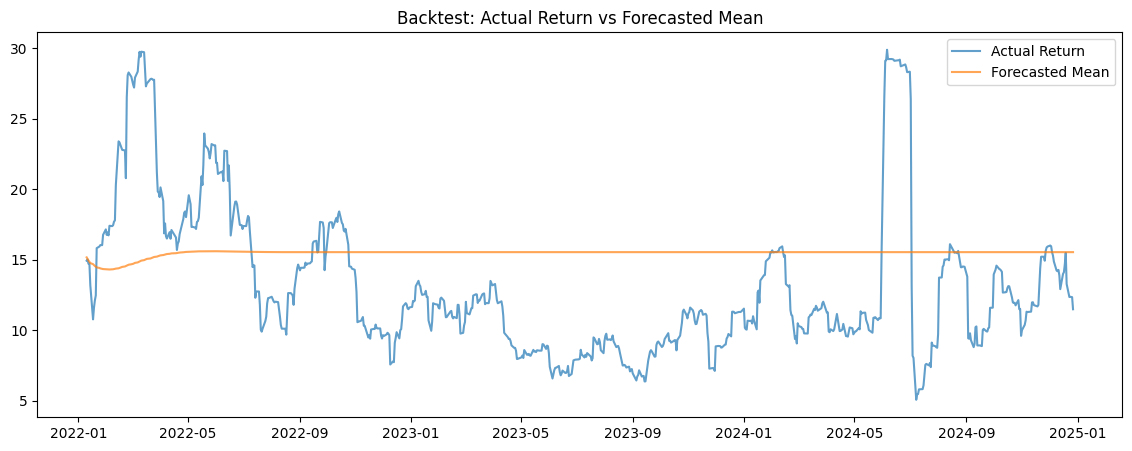

In [193]:
plt.figure(figsize=(14, 5))
plt.plot(backtest_df.index, backtest_df["Actual_Return"], label="Actual Return", alpha=0.7)
plt.plot(backtest_df.index, backtest_df["Mean_Forecast"], label="Forecasted Mean", alpha=0.7)
plt.title("Backtest: Actual Return vs Forecasted Mean")
plt.legend()
plt.show()

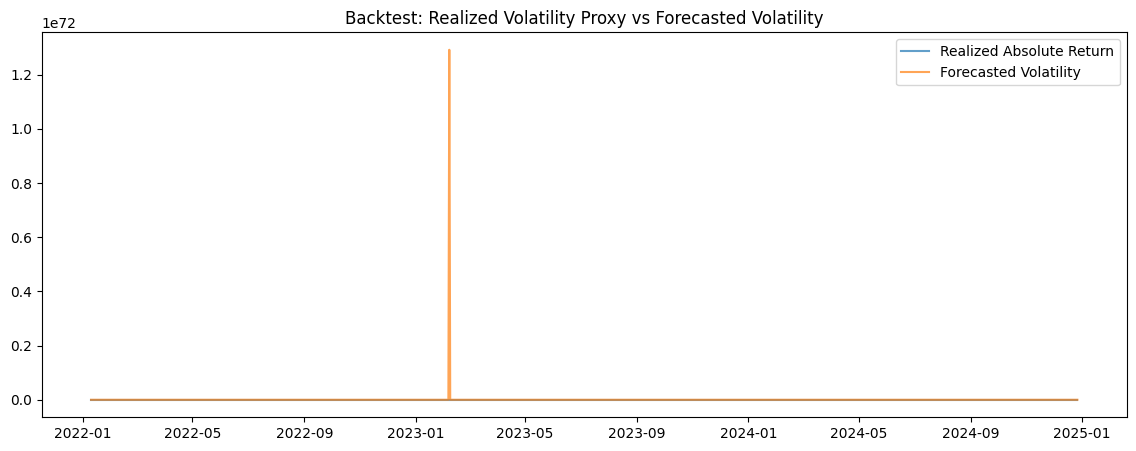

In [195]:
plt.figure(figsize=(14, 5))
plt.plot(backtest_df.index, backtest_df["Realized_Abs_Return"], label="Realized Absolute Return", alpha=0.7)
plt.plot(backtest_df.index, backtest_df["Volatility_Forecast"], label="Forecasted Volatility", alpha=0.7)
plt.title("Backtest: Realized Volatility Proxy vs Forecasted Volatility")
plt.legend()
plt.show()

In [205]:
print("Backtesting Summary")
print("-------------------")
print("Mean Forecast MAE :", mae_mean)
print("Mean Forecast RMSE:", rmse_mean)
print("Vol Forecast MAE  :", mae_vol)
print("Vol Forecast RMSE :", rmse_vol)

Backtesting Summary
-------------------
Mean Forecast MAE : 4.973468276052491
Mean Forecast RMSE: 5.877274152111509
Vol Forecast MAE  : 1.764943380250317e+69
Vol Forecast RMSE : 4.775142300684087e+70
